In [1]:
import sys
from functools import partial
sys.path.append('../')
from math import log, comb, cos, sin
from numpy.linalg import matrix_power
from spd.OperatorSequence import *
from spd.SparsePauliDynamics import *
from spd.LightPauliDynamics import *
from pauli import *
from quantum_simulation_recipe.spin import Nearest_Neighbour_1d
from quantum_simulation_recipe.trotter import pf, expH
from qiskit.quantum_info import SparsePauliOp, random_statevector
import matplotlib.pyplot as plt
from quantum_simulation_recipe.plot_config import *
set_fontsize(linewidth=2.5)
fig_dir, data_dir = './figs', './data'

## OTOC

In [2]:
n = 8 # 10
t = 5
r = 50 # 100

dt = t/r
H_model = 'MFI'
Jz, hx, hz = -1, 1.05, 0.5
# n = 21
qimf = Nearest_Neighbour_1d(n, hx=hx, hz=hz, Jz=Jz, pbc=False)
zz_even = SparsePauliOp.from_sparse_list([*qimf.zz_tuples[::2]], num_qubits=n).simplify()
zz_odd = SparsePauliOp.from_sparse_list([*qimf.zz_tuples[1::2]], num_qubits=n).simplify()
z_terms = SparsePauliOp.from_sparse_list([*qimf.z_tuples], num_qubits=n).simplify()
x_terms = qimf.x_terms
H_list = [x_terms, z_terms, zz_even, zz_odd] # [xx_even, x_terms, qimf.y_terms,xx_odd]
H_pf2_list = [x_terms, z_terms, zz_even, zz_odd, zz_odd, zz_even, z_terms, x_terms] 
H_ordered = sum(H_list)
H_pf2_ordered = sum(H_pf2_list)
dt = t/r
print(f't={t}, r={r}, dt={dt}')
U_dt_ideal = expH(sum(H_ordered), dt, use_jax=True)
U_dt_appro = pf(H_ordered, dt, 2, 1)
# init_state_str = '0'*n
init_state_str = '00'*(n//2)
init_state = Statevector.from_label(init_state_str).data

z1 = SparsePauliOp('I'*(n-1)+'Z', 1)
x4 = SparsePauliOp('I'*(n-4)+'X'+'I'*3, 1)
complete_fnorm = 2**(-n/2)*np.linalg.norm(z1.to_matrix(), ord='fro')

ops = dt*sum(H_ordered)

def otoc_k(Bt, M, k=1):
    Bt_M = Bt @ M
    res = Bt.conjugate().transpose() @ M.conjugate().transpose() @ Bt @ M
    # res = Bt_M
    # for _ in range(2*k-1):
    #     # print('-')
    #     res = Bt_M @ Bt_M
    return res
    # return matrix_power(A_t_B, k)
print(otoc_k(z1, x4, k=1))

B0, M = x4, z1

t=5, r=50, dt=0.1
SparsePauliOp(['IIIIIIII'],
              coeffs=[1.+0.j])


In [3]:
exp_val_func = partial(exp_val_0101_state_pauli_rep, n_qubits=n)
w_thres = 4
sim = LowWeightPauliPropagation.from_pauli_list(B0, ops, threshold=w_thres, nprocs=4)
res = sim.run_dynamics(r, process=exp_val_func, process_every=1, verbose=False)
res = np.array(res)
# res = res / res[0].sum()

sim1 = LowWeightPauliPropagation.from_pauli_list(B0, ops, threshold=w_thres+1, nprocs=4)
res1 = sim1.run_dynamics(r, process=exp_val_func, process_every=1, verbose=False)
res1 = np.array(res1)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
100%|██████████| 50/50 [00:02<00:00, 23.08it/s]


(0.01253607160786889-2.015124332900778e-18j)


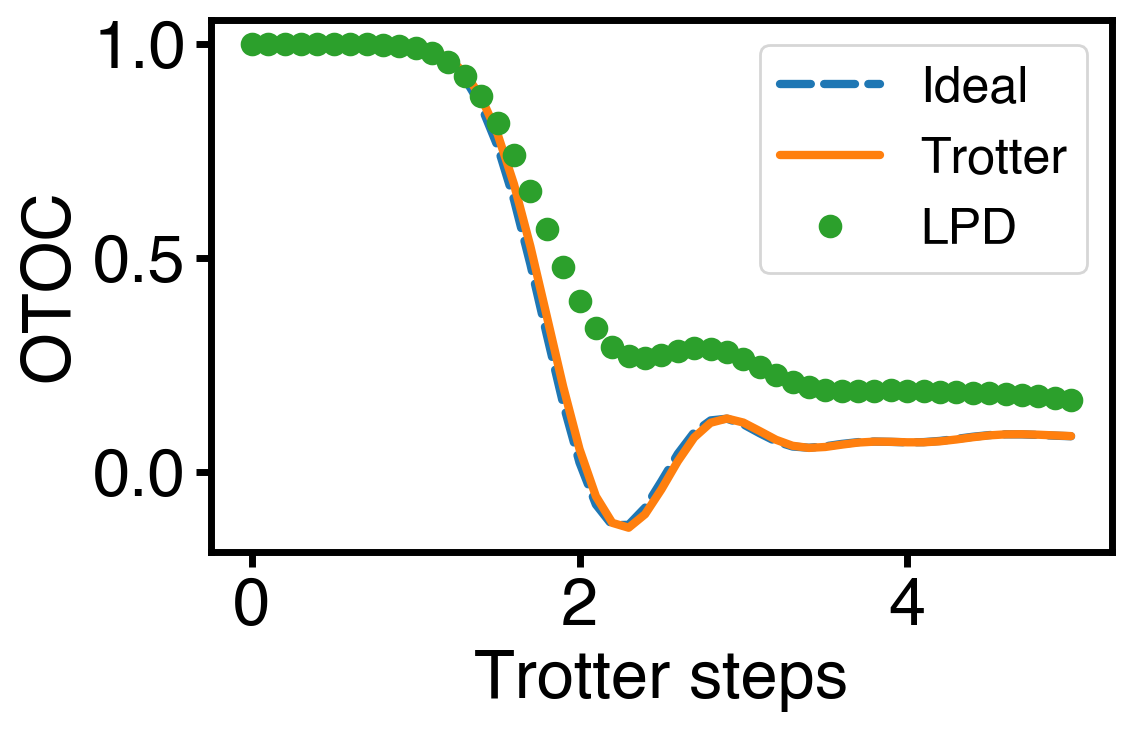

In [5]:
trott_ops = [matrix_power(U_dt_appro, i) for i in range(r+1)]
ideal_ops = [matrix_power(U_dt_ideal, i) for i in range(r+1)]
trott_Bt = [op.conjugate().transpose() @ B0.to_matrix() @ op for op in trott_ops]
ideal_Bt = [op.conjugate().transpose() @ B0.to_matrix() @ op for op in ideal_ops]

# print('obs:', obs)
# otoc_ideal_list = [expect_value(otoc_k(At, B.to_matrix(), k=2), init_state, tol=1e-7) for At in ideal_At]
# otoc_trott_list = [expect_value(otoc_k(At, B.to_matrix(), k=2), init_state, tol=1e-7) for At in trott_At]
print(init_state.conj().T @ otoc_k(ideal_Bt[33], M.to_matrix(), k=1) @ init_state)
otoc_ideal_list = [np.trace(otoc_k(Bt, M.to_matrix(), k=1))/2**n for Bt in ideal_Bt]
otoc_trott_list = [np.trace(otoc_k(Bt, M.to_matrix(), k=1))/2**n for Bt in trott_Bt]
otoc_lpd_list = [np.trace(otoc_k(Bt.to_sparse_pauli_op(n).to_matrix(), M.to_matrix(), k=1))/2**n for Bt in sim1.evo_obs]
# otoc_lpd_list = [np.trace(otoc_k(Bt.to_sparse_pauli_op(n), M, k=1))/2**n for Bt in sim1.evo_obs]
# otoc_lpd_list = [np.trace((Bt.to_sparse_pauli_op(n)@M).simplify()@(Bt.to_sparse_pauli_op(n)@M).simplify())/2**n for Bt in sim1.evo_obs]
# otoc_ideal_list = [expect_value(At, init_state, tol=1e-15) for At in ideal_At]
# otoc_trott_list = [expect_value(At, init_state, tol=1e-15) for At in trott_At]

fig, ax = plt.subplots(figsize=(6,4))
t_list = [dt*i for i in range(r+1)]
assert np.imag(otoc_ideal_list).max()<1e-12 and np.imag(otoc_trott_list).max()<1e-12
ax.plot(t_list, np.real(otoc_ideal_list), '--', label='Ideal')
ax.plot(t_list, np.real(otoc_trott_list), label='Trotter')
ax.plot(t_list, np.real(otoc_lpd_list), '.', label='LPD')
ax.set_xlabel('Trotter steps')
ax.set_ylabel('OTOC')
ax.legend()

fig.savefig(f'{fig_dir}/otoc_mfi_n={n}_t={t}_r={r}_w={w_thres}.pdf')

In [3]:
evo_obs = [item.to_sparse_pauli_op(n) for item in sim1.evo_obs]
norm_weight_steps = []
for i, ob in enumerate(sim1.evo_obs):
    temp_step = []
    # print(i, norm_weight_steps)
    for w in range(1, n+1):
        ob_w = decompose_by_weight_pauli_rep(ob)
        # print(ob_w)
        if w in ob_w:
            temp_step.append(ob_w[w].p2norm()**2)
        else:
            # print(f'No weight {w} Paulis')
            temp_step.append(0)
    norm_weight_steps.append(temp_step)

pauli_diff_fnorm = [2**(-n/2)*np.linalg.norm(ob.to_matrix() - trott_obs[i], ord='fro')/complete_fnorm for i, ob in enumerate(evo_obs)]
print(pauli_diff_fnorm)
trott_diff_fnorm = [2**(-n/2)*np.linalg.norm(ob - trott_obs[i], ord='fro')/complete_fnorm for i, ob in enumerate(ideal_obs)]

n_states = 50
# rand_states = [random_statevector(2**n) for _ in range(n_states)]
from input_states import generate_clifford_states
rand_states = generate_clifford_states(n, n_states)
## random computational basis states
# rand_states = [Statevector.from_label(''.join(np.random.choice(['0', '1'], n))) for _ in range(n_states)]
# Verify 2-design property using Haar random states
expvals_pauli_diff = [[abs(states.expectation_value(ob.to_matrix() - trott_obs[i])) for states in rand_states] for i, ob in enumerate(evo_obs)]
print('expval_trotter_diff')
expvals_trott_diff = [[abs(states.expectation_value(ob - trott_obs[i])) for states in rand_states] for i, ob in enumerate(ideal_obs)]

NameError: name 'sim1' is not defined

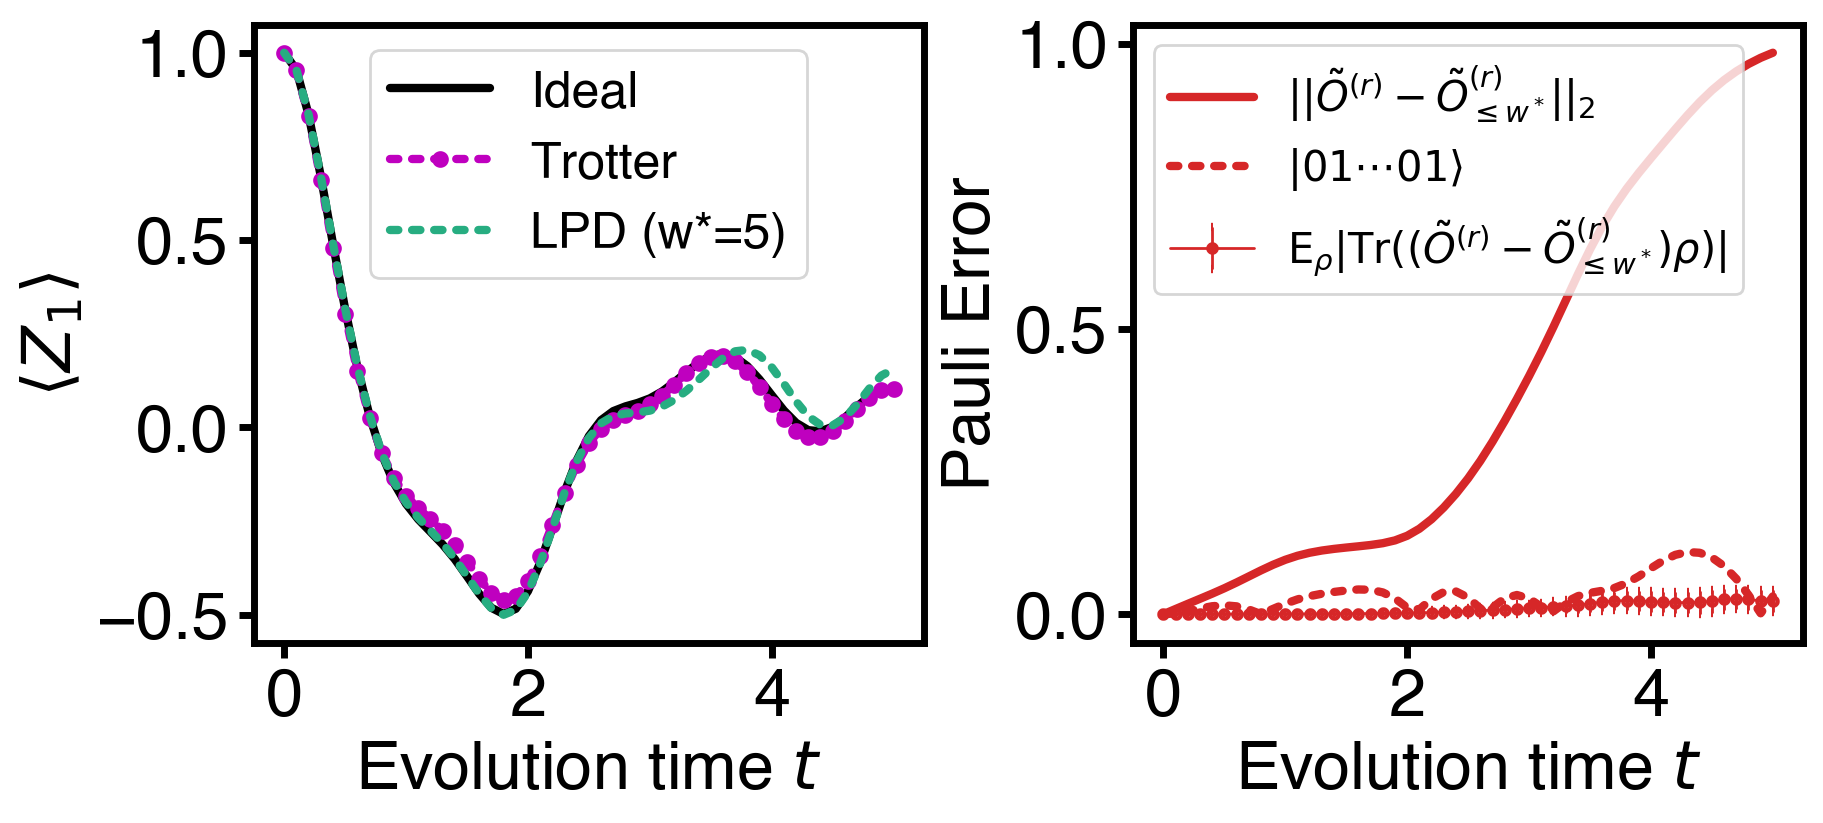

In [22]:
cc = default_color_cycle

t_dense_list = np.array(range(len(ideal_expvals))) * t/t_num_dense
t_list = np.array(range(len(trott_expvals))) * dt
colors = plt.cm.viridis(np.linspace(0.4, 0.9, n))
# colors = plt.cm.plasma(np.linspace(0.3, 0.9, n))

fig, axes = plt.subplots(1, 2, figsize=(9, 4), layout='constrained') 
axes[0].plot(t_dense_list, ideal_expvals, '-', label='Ideal', c='k')
axes[0].plot(t_list, trott_expvals, ':.', label='Trotter', c="m", ms=6)
# axes[0].plot(t_list, res.real, '--', label=f'LPD (w*={w_thres})', c=colors[w_thres-1])
axes[0].plot(t_list, res1.real, ':', label=f'LPD (w*={w_thres+1})', c=colors[w_thres])
axes[0].set_xlabel(rf'Evolution time $t$'); 
axes[0].set_ylabel(rf'$\langle Z_1 \rangle$')
axes[0].legend(loc='upper center', fontsize=18, ncol=1)
# axes[0,0].set_title(rf'{H_model}, n={n}, t={t}, r={r}, init={init_state_str[:2]}')

axes[1].plot(t_list, pauli_diff_fnorm, '-', label=r'$||\tilde{O}^{(r)}-\tilde{O}^{(r)}_{\leq  w^*}||_2$', c='tab:red')
axes[1].errorbar(t_list, np.array(expvals_pauli_diff).mean(axis=1), yerr=np.array(expvals_pauli_diff).std(axis=1), fmt='.-', label=r'$\mathbb{\text{E}}_{\rho}|\text{Tr}((\tilde{O}^{(r)}-\tilde{O}^{(r)}_{\leq w^*})\rho)|$', c='tab:red', capsize=0.5, lw=1, ms=3)
axes[1].plot(t_list, abs(trott_expvals-res), ':', label=r'$|01\cdots 01\rangle $', c='tab:red')
axes[1].set_ylabel(rf'Pauli Error'); axes[1].legend(loc='upper left', fontsize='small')
axes[1].set_xlabel(rf'Evolution time $t$'); 

# for ax, label in zip(axes.flatten(), ['a', 'b']): 
#     ax.text(-0.10, 1.15, label, transform=ax.transAxes, fontsize=24, va='top', weight='bold')

fig.savefig(f'{fig_dir}/LPD_{H_model}_n={n}_t={t}_r={r}_w={w_thres}_{init_state_str[:4]}_PF2.pdf', bbox_inches='tight')

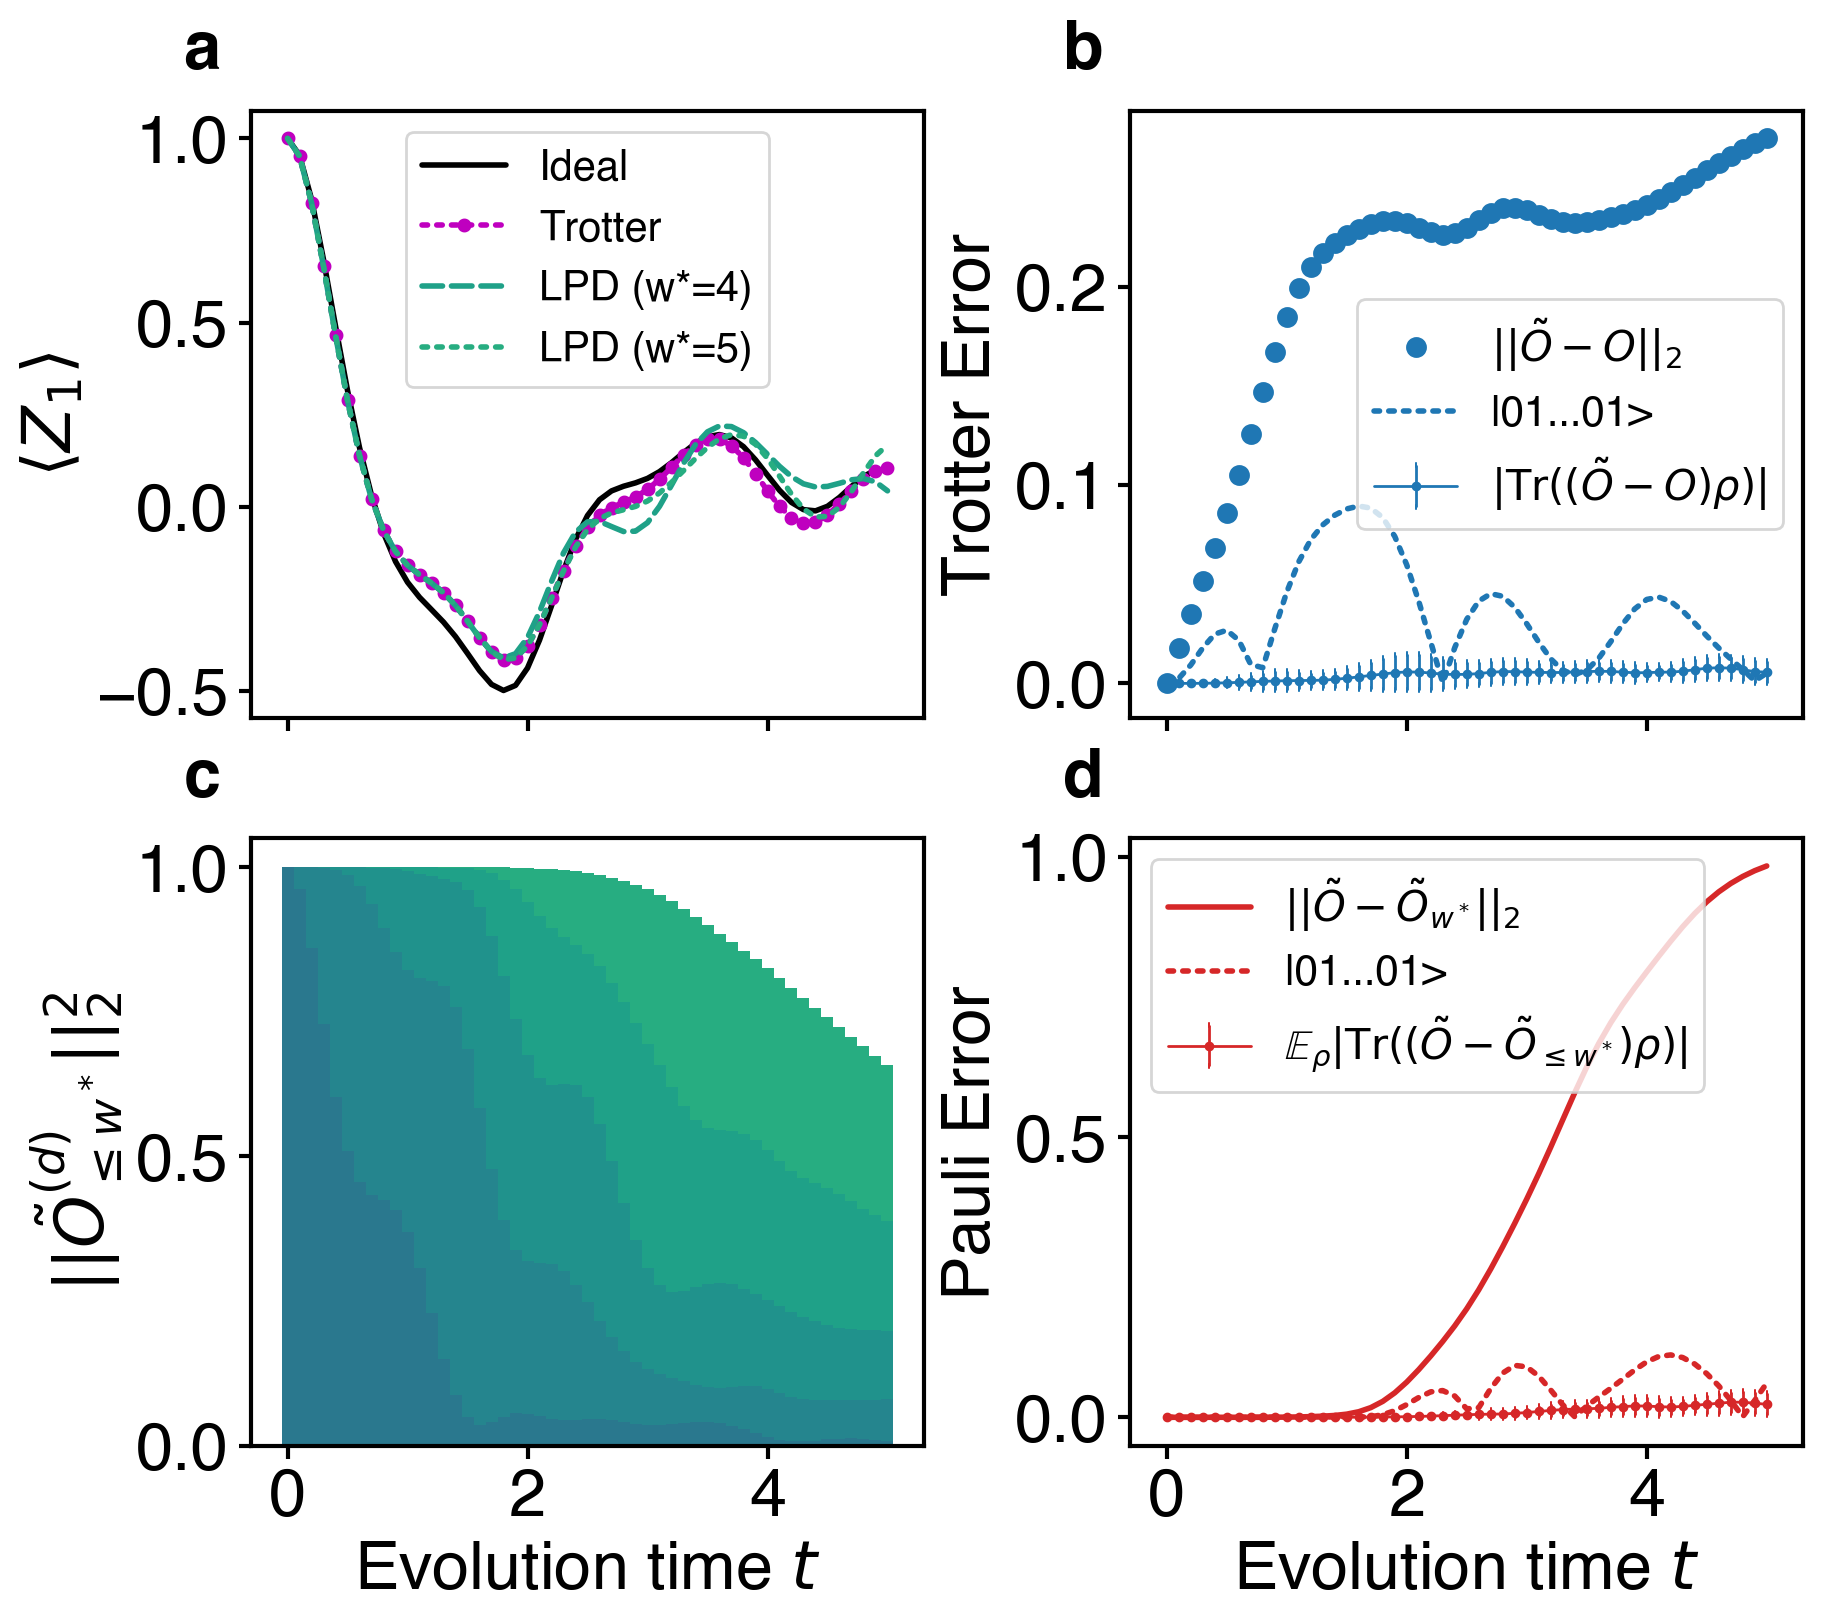

In [21]:
t_dense_list = np.array(range(len(ideal_expvals))) * t/t_num_dense
t_list = np.array(range(len(trott_expvals))) * dt
colors = plt.cm.viridis(np.linspace(0.4, 0.9, n))
# colors = plt.cm.plasma(np.linspace(0.3, 0.9, n))

fig, axes = plt.subplots(2, 2, sharex=True, figsize=(9, 8), layout='constrained') # , layout='constrained'
axes[0,0].plot(t_dense_list, ideal_expvals, '-', label='Ideal', c='k')
axes[0,0].plot(t_list, trott_expvals, ':.', label='Trotter', c='m', ms=6)
axes[0,0].plot(t_list, res.real, '--', label=f'LPD (w*={w_thres})', c=colors[w_thres-1])
axes[0,0].plot(t_list, res1.real, ':', label=f'LPD (w*={w_thres+1})', c=colors[w_thres])
axes[1,0].set_xlabel(rf'Evolution time $t$'); 
axes[0,0].set_ylabel(rf'$\langle Z_1 \rangle$')
axes[0,0].legend(loc='upper center', fontsize='small', ncol=1)
# axes[0,0].set_title(rf'{H_model}, n={n}, t={t}, r={r}, init={init_state_str[:2]}')

axes[1,1].plot(t_list, pauli_diff_fnorm, '-', label=r'$||\tilde{O}-\tilde{O}_{ w^*}||_2$', c='tab:red')
axes[1,1].errorbar(t_list, np.array(expvals_pauli_diff).mean(axis=1), yerr=np.array(expvals_pauli_diff).std(axis=1), fmt='.-', label=r'$\mathbb{E}_{\rho}|\text{Tr}((\tilde{O}-\tilde{O}_{\leq w^*})\rho)|$', c='tab:red', capsize=0.5, lw=1, ms=3)
axes[1,1].plot(t_list, abs(trott_expvals-res), ':', label=f'|01...01>', c='tab:red')
axes[1,1].set_ylabel(rf'Pauli Error'); axes[1,1].legend(loc='upper left', fontsize='small')
axes[1,1].set_xlabel(rf'Evolution time $t$'); 
axes[0,1].plot(t_list, trott_diff_fnorm, '.', label=r'$||\tilde{O}-O||_2$', c='tab:blue')
axes[0,1].errorbar(t_list, np.array(expvals_trott_diff).mean(axis=1), yerr=np.array(expvals_trott_diff).std(axis=1), fmt='.-', label=r'$|\text{Tr}((\tilde{O}-O)\rho)|$', c='tab:blue', capsize=0.5, lw=1, ms=3)
axes[0,1].plot(t_list, abs(np.array(trott_expvals)-np.array(ideal_expvals)), ':', label=f'|01...01>', c='tab:blue')
axes[0,1].set_ylabel(rf'Trotter Error'); axes[0,1].legend(loc='center right', fontsize='small')

for w in range(n, 0, -1):
    norm2_distr = [sum(norm_weight_steps[i][:w]) for i in range(len(trott_expvals))]
    # if w<=7: print(f'w>={w+1},', 1-norm2_distr[-1])
    bars = axes[1,0].bar(t_list, norm2_distr, 0.1, color=colors[w-1], label=f'w<={w}')
axes[1,0].set_ylabel(r'$||\tilde{O}_{\leq w^*}^{(d)}||_2^2$') # axes[1,0].legend(loc='upper right')

for ax, label in zip(axes.flatten(), ['a', 'b', 'c', 'd']): 
    ax.text(-0.10, 1.15, label, transform=ax.transAxes, fontsize=24, va='top', weight='bold')

fig.savefig(f'{fig_dir}/LPD_{H_model}_n={n}_t={t}_r={r}_w={w_thres}_{init_state_str[:4]}_2design.pdf', bbox_inches='tight')